In [1]:
# =========================
# IMPORTS
# =========================

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer

# =========================
# LOAD CLINICAL DATA
# =========================

clinical_full = pd.read_csv("ADSL.csv")

print("Clinical raw shape:", clinical_full.shape)

print("\nDX distribution:")
print(clinical_full["DX"].value_counts(dropna=False))

# =========================
# CREATE LABELS
# =========================

clinical_full = clinical_full[
    clinical_full["DX"].isin(["CN", "DEM"])
].copy()

clinical_full["LABEL"] = clinical_full["DX"].map({
    "CN": 0,
    "DEM": 1
})

print("\nLabel counts:")
print(clinical_full["LABEL"].value_counts())

# =========================
# BUILD CLINICAL DATASET
# =========================

clinical = clinical_full[[
    "SUBJID",
    "AGE",
    "SEX",
    "EDUC",
    "MMSCORE",
    "MOCA",
    "CDRSB",
    "FAQTOTAL",
    "RAVLTFG",
    "RAVLTIMM",
    "TRABSCOR",
    "LABEL"
]].copy()

# =========================
# CLEAN CLINICAL DATA
# =========================

clinical = clinical.rename(columns={
    "SUBJID": "RID"
})

clinical["SEX"] = clinical["SEX"].map({
    "Male": 0,
    "Female": 1
})

clinical = clinical.dropna()

clinical = clinical.drop_duplicates(
    subset="RID"
)

print("\nClinical cleaned shape:", clinical.shape)

# =========================
# LOAD MRI DATA
# =========================

mri = pd.read_csv("UCSFFSX6.csv")

print("\nMRI raw shape:", mri.shape)

# =========================
# KEEP LATEST MRI SCAN
# =========================

mri["EXAMDATE"] = pd.to_datetime(
    mri["EXAMDATE"]
)

mri = mri.sort_values("EXAMDATE")

mri = mri.drop_duplicates(
    subset="RID",
    keep="last"
)

print("\nMRI deduplicated shape:", mri.shape)

# =========================
# MRI FEATURE FILTERING
# =========================

numeric_cols = mri.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

drop_cols = ["RID", "IMAGEUID"]

mri_features = [
    c for c in numeric_cols
    if c not in drop_cols
]

# =========================
# REMOVE HIGH-MISSING FEATURES
# =========================

missing_pct = mri[mri_features].isnull().mean()

good_features = missing_pct[
    missing_pct < 0.3
].index.tolist()

mri = mri[["RID"] + good_features]

print("\nMRI feature count after filtering:", len(good_features))

# =========================
# MERGE
# =========================

merged = pd.merge(
    clinical,
    mri,
    on="RID",
    how="inner"
)

print("\nMerged shape BEFORE imputation:", merged.shape)

# =========================
# IMPUTATION
# =========================

feature_cols = [
    c for c in merged.columns
    if c not in ["RID", "LABEL"]
]

imputer = SimpleImputer(
    strategy="median"
)

merged[feature_cols] = imputer.fit_transform(
    merged[feature_cols]
)

# =========================
# TOP MRI FEATURES
# =========================

mri_features = [
    c for c in merged.columns
    if c.startswith("ST")
]

mri_variance = merged[mri_features].var()

top_mri_features = (
    mri_variance
    .sort_values(ascending=False)
    .head(30)
    .index
    .tolist()
)

print("\nTop MRI features:")
print(top_mri_features)

# =========================
# FINAL FEATURES
# =========================

clinical_features = [
    "AGE",
    "SEX",
    "EDUC",
    "RAVLTFG",
    "RAVLTIMM",
    "TRABSCOR"
]

final_features = (
    clinical_features
    + top_mri_features
)

# =========================
# BUILD X/y
# =========================

X = merged[final_features]

y = merged["LABEL"]

# =========================
# FINAL DIAGNOSTICS
# =========================

print("\n===== FINAL DATASET =====")

print("Shape:", merged.shape)

print("\nLabel distribution:")
print(y.value_counts())

print("\nMissing values:")
print(merged.isnull().sum().sum())

print("\nDuplicate RIDs:")
print(merged["RID"].duplicated().sum())

Clinical raw shape: (5146, 55)

DX distribution:
DX
NaN    2116
MCI    1338
CN     1215
DEM     477
Name: count, dtype: int64

Label counts:
LABEL
0    1215
1     477
Name: count, dtype: int64

Clinical cleaned shape: (772, 12)

MRI raw shape: (2270, 347)

MRI deduplicated shape: (1130, 347)

MRI feature count after filtering: 323

Merged shape BEFORE imputation: (412, 335)

Top MRI features:
['ST10CV', 'ST155SV', 'ST154SV', 'ST152SV', 'ST149SV', 'ST150SV', 'ST151SV', 'ST147SV', 'ST148SV', 'ST37SV', 'ST96SV', 'ST87sa', 'ST28SA', 'ST76SV', 'ST17SV', 'ST128SV', 'ST153SV', 'ST1SV', 'ST115CV', 'ST56CV', 'ST18SV', 'ST77SV', 'ST114CV', 'ST55CV', 'ST90CV', 'ST32CV', 'ST31CV', 'ST57CV', 'ST116CV', 'ST91CV']

===== FINAL DATASET =====
Shape: (412, 335)

Label distribution:
LABEL
0    351
1     61
Name: count, dtype: int64

Missing values:
0

Duplicate RIDs:
0


In [2]:
# =========================
# TRAIN / TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain labels:")
print(y_train.value_counts())

print("\nTest labels:")
print(y_test.value_counts())

# =========================
# SCALE FEATURES
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# =========================
# IMPORT MODELS
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

# =========================
# DEFINE MODELS
# =========================

models = {

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )
}

# =========================
# MODEL COMPARISON
# =========================

results = []

for name, model in models.items():

    print(f"\n===== TRAINING {name} =====")

    model.fit(X_train_scaled, y_train)

    probs = model.predict_proba(
        X_test_scaled
    )[:, 1]

    preds = model.predict(
        X_test_scaled
    )

    auc = roc_auc_score(
        y_test,
        probs
    )

    results.append({
        "Model": name,
        "AUC": auc
    })

    print("AUC:", auc)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        preds
    ))

# =========================
# RESULTS DATAFRAME
# =========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="AUC",
    ascending=False
)

print("\n===== MODEL COMPARISON =====")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("\nBest Model:", best_model_name)

Train shape: (329, 36)
Test shape: (83, 36)

Train labels:
LABEL
0    280
1     49
Name: count, dtype: int64

Test labels:
LABEL
0    71
1    12
Name: count, dtype: int64

===== TRAINING Logistic Regression =====
AUC: 0.9765258215962441

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        71
           1       0.79      0.92      0.85        12

    accuracy                           0.95        83
   macro avg       0.89      0.94      0.91        83
weighted avg       0.96      0.95      0.95        83


===== TRAINING Random Forest =====
AUC: 0.942488262910798

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.89      0.67      0.76        12

    accuracy                           0.94        83
   macro avg       0.92      0.83      0.86        83
weighted avg       0.94      0.94      0.94        83


=

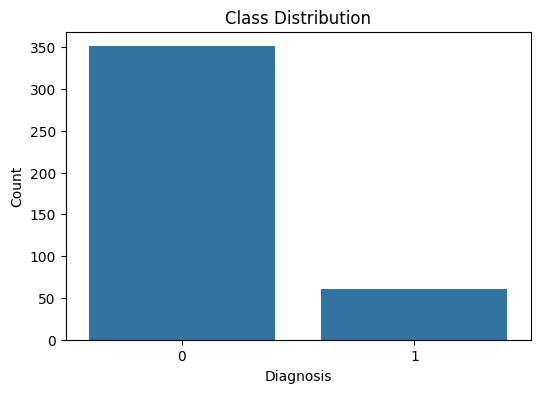

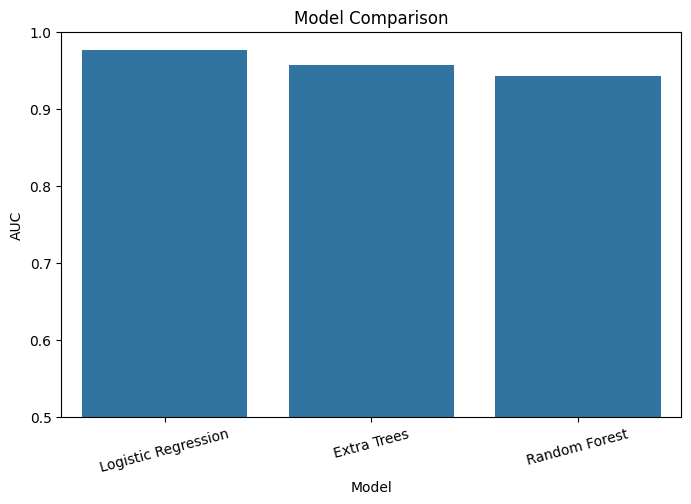

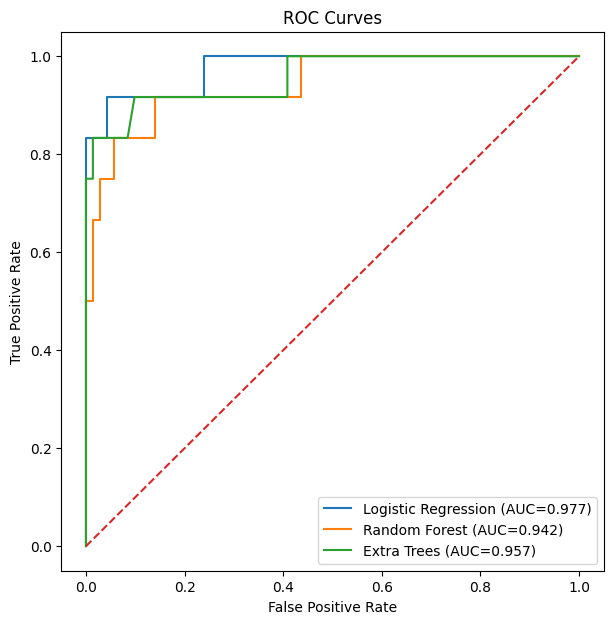

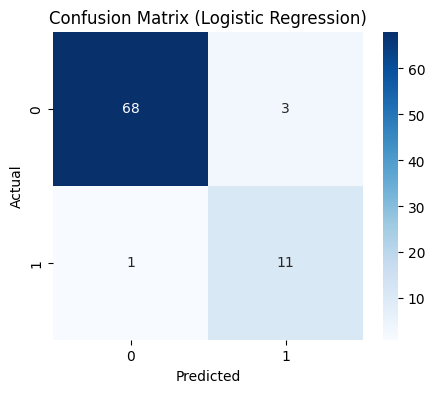

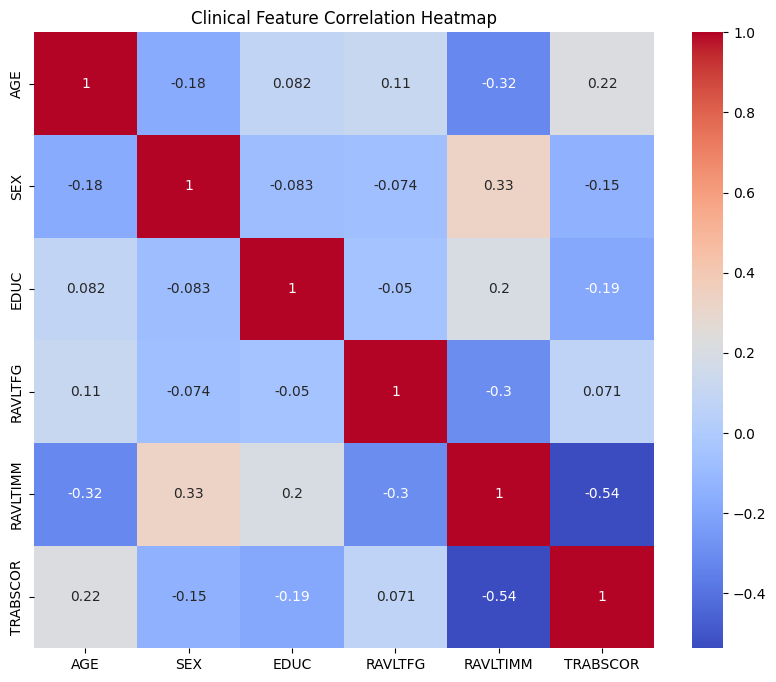

In [3]:
# =========================
# CLASS DISTRIBUTION
# =========================

plt.figure(figsize=(6,4))

sns.countplot(
    x=y
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()


# =========================
# MODEL COMPARISON BARPLOT
# =========================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="AUC"
)

plt.title("Model Comparison")

plt.ylim(0.5, 1.0)

plt.xticks(rotation=15)

plt.show()


# =========================
# ROC CURVES FOR ALL MODELS
# =========================

from sklearn.metrics import roc_curve

plt.figure(figsize=(7,7))

for name, model in models.items():

    model.fit(
        X_train_scaled,
        y_train
    )

    probs = model.predict_proba(
        X_test_scaled
    )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    auc = roc_auc_score(
        y_test,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.show()


# =========================
# CONFUSION MATRIX
# =========================

from sklearn.metrics import confusion_matrix

best_model.fit(
    X_train_scaled,
    y_train
)

best_preds = best_model.predict(
    X_test_scaled
)

cm = confusion_matrix(
    y_test,
    best_preds
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix ({best_model_name})")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# =========================
# FEATURE IMPORTANCE
# =========================

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": final_features,
        "Importance": best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n===== TOP FEATURES =====")
    print(importance_df.head(20))

    top_features = importance_df.head(15)

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature"
    )

    plt.title("Top Feature Importances")

    plt.show()


# =========================
# CLINICAL CORRELATION HEATMAP
# =========================

plt.figure(figsize=(10,8))

sns.heatmap(
    merged[clinical_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Clinical Feature Correlation Heatmap")

plt.show()

In [4]:
# =====================================================
# MISSING CLINICAL MODALITY EXPERIMENT
# =====================================================

# Create copy of test data
X_test_missing = X_test.copy()

# Remove clinical modality
X_test_missing[clinical_features] = 0

# Scale using SAME scaler
X_test_missing_scaled = scaler.transform(
    X_test_missing
)

# Predict
missing_probs = best_model.predict_proba(
    X_test_missing_scaled
)[:,1]

# Evaluate
from sklearn.metrics import roc_auc_score

missing_auc = roc_auc_score(
    y_test,
    missing_probs
)

print("Baseline AUC:")
print(results_df.iloc[0]["AUC"])

print("\nAUC with missing clinical modality:")
print(missing_auc)

print("\nPerformance Drop:")
print(
    results_df.iloc[0]["AUC"] - missing_auc
)

Baseline AUC:
0.9765258215962441

AUC with missing clinical modality:
0.7711267605633803

Performance Drop:
0.20539906103286387


In [5]:
# =====================================================
# ROBUSTNESS TRAINING
# RANDOM CLINICAL MODALITY DROPOUT
# =====================================================

import numpy as np

# Copy training data
X_train_robust = X_train.copy()

# Randomly choose rows
mask = np.random.rand(
    len(X_train_robust)
) < 0.3

# Remove clinical modality
X_train_robust.loc[
    mask,
    clinical_features
] = 0

print("Rows with dropped clinical modality:")
print(mask.sum())

# =====================================================
# SCALE
# =====================================================

from sklearn.preprocessing import StandardScaler

robust_scaler = StandardScaler()

X_train_robust_scaled = robust_scaler.fit_transform(
    X_train_robust
)

X_test_scaled_robust = robust_scaler.transform(
    X_test
)

X_test_missing_scaled_robust = robust_scaler.transform(
    X_test_missing
)

# =====================================================
# TRAIN ROBUST MODEL
# =====================================================

from sklearn.linear_model import LogisticRegression

robust_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

robust_model.fit(
    X_train_robust_scaled,
    y_train
)

# =====================================================
# EVALUATE FULL TEST DATA
# =====================================================

robust_full_probs = robust_model.predict_proba(
    X_test_scaled_robust
)[:,1]

robust_full_auc = roc_auc_score(
    y_test,
    robust_full_probs
)

# =====================================================
# EVALUATE MISSING MODALITY TEST DATA
# =====================================================

robust_missing_probs = robust_model.predict_proba(
    X_test_missing_scaled_robust
)[:,1]

robust_missing_auc = roc_auc_score(
    y_test,
    robust_missing_probs
)

# =====================================================
# RESULTS
# =====================================================

print("\n===== ROBUSTNESS RESULTS =====")

print("\nOriginal Full AUC:")
print(results_df.iloc[0]["AUC"])

print("\nOriginal Missing-Modality AUC:")
print(missing_auc)

print("\nRobust Model Full AUC:")
print(robust_full_auc)

print("\nRobust Model Missing-Modality AUC:")
print(robust_missing_auc)

print("\nOriginal Performance Drop:")
print(
    results_df.iloc[0]["AUC"] - missing_auc
)

print("\nRobust Performance Drop:")
print(
    robust_full_auc - robust_missing_auc
)

Rows with dropped clinical modality:
99

===== ROBUSTNESS RESULTS =====

Original Full AUC:
0.9765258215962441

Original Missing-Modality AUC:
0.7711267605633803

Robust Model Full AUC:
0.9694835680751175

Robust Model Missing-Modality AUC:
0.8086854460093897

Original Performance Drop:
0.20539906103286387

Robust Performance Drop:
0.16079812206572774



FINAL CROSS-VALIDATED RESULTS TABLE
      Model  Mean Full AUC Mean Missing AUC Mean Performance Drop
0  Baseline  0.980 ± 0.007    0.840 ± 0.034         0.140 ± 0.028
1    Robust  0.977 ± 0.008    0.863 ± 0.042         0.114 ± 0.037


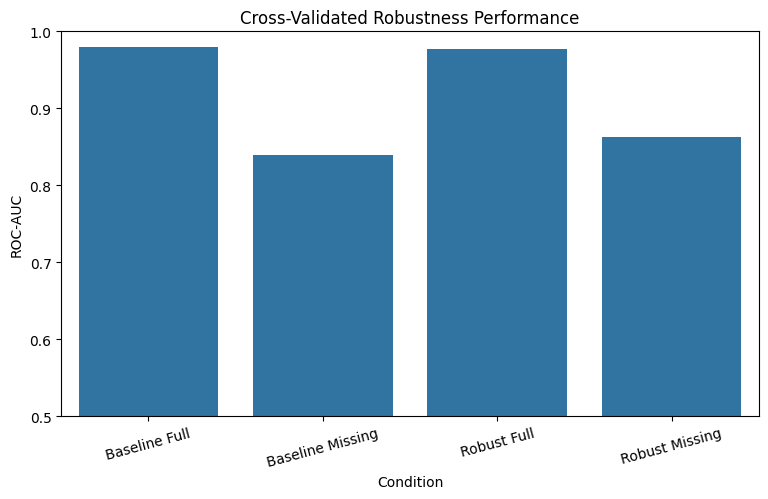

In [10]:
# =====================================================
# FINAL PAPER RESULTS TABLE
# =====================================================

# -----------------------------------------
# STANDARD ERRORS
# -----------------------------------------

baseline_full_std = np.std(
    baseline_full_aucs
)

baseline_missing_std = np.std(
    baseline_missing_aucs
)

robust_full_std = np.std(
    robust_full_aucs
)

robust_missing_std = np.std(
    robust_missing_aucs
)

# -----------------------------------------
# PERFORMANCE DROPS PER FOLD
# -----------------------------------------

baseline_drops = [

    full - missing

    for full, missing in zip(
        baseline_full_aucs,
        baseline_missing_aucs
    )
]

robust_drops = [

    full - missing

    for full, missing in zip(
        robust_full_aucs,
        robust_missing_aucs
    )
]

baseline_drop_mean = np.mean(
    baseline_drops
)

baseline_drop_std = np.std(
    baseline_drops
)

robust_drop_mean = np.mean(
    robust_drops
)

robust_drop_std = np.std(
    robust_drops
)

# =====================================================
# FINAL RESULTS TABLE
# =====================================================

paper_results = pd.DataFrame({

    "Model": [
        "Baseline",
        "Robust"
    ],

    "Mean Full AUC": [

        f"{np.mean(baseline_full_aucs):.3f} ± {baseline_full_std:.3f}",

        f"{np.mean(robust_full_aucs):.3f} ± {robust_full_std:.3f}"
    ],

    "Mean Missing AUC": [

        f"{np.mean(baseline_missing_aucs):.3f} ± {baseline_missing_std:.3f}",

        f"{np.mean(robust_missing_aucs):.3f} ± {robust_missing_std:.3f}"
    ],

    "Mean Performance Drop": [

        f"{baseline_drop_mean:.3f} ± {baseline_drop_std:.3f}",

        f"{robust_drop_mean:.3f} ± {robust_drop_std:.3f}"
    ]
})

# =====================================================
# DISPLAY TABLE
# =====================================================

print("\n========================================")
print("FINAL CROSS-VALIDATED RESULTS TABLE")
print("========================================")

print(paper_results)

# =====================================================
# SAVE RESULTS
# =====================================================

paper_results.to_csv(
    "final_results_table.csv",
    index=False
)

# =====================================================
# VISUALIZATION
# =====================================================

plot_df = pd.DataFrame({

    "Condition": [

        "Baseline Full",
        "Baseline Missing",

        "Robust Full",
        "Robust Missing"
    ],

    "Mean AUC": [

        np.mean(baseline_full_aucs),

        np.mean(baseline_missing_aucs),

        np.mean(robust_full_aucs),

        np.mean(robust_missing_aucs)
    ]
})

plt.figure(figsize=(9,5))

sns.barplot(
    data=plot_df,
    x="Condition",
    y="Mean AUC"
)

plt.ylim(0.5, 1.0)

plt.title(
    "Cross-Validated Robustness Performance"
)

plt.ylabel("ROC-AUC")

plt.xticks(rotation=15)

plt.show()


MISSINGNESS LEVEL: 10%
Baseline AUC:
0.9190140845070423

Robust AUC:
0.9870892018779343

MISSINGNESS LEVEL: 30%
Baseline AUC:
0.8791079812206573

Robust AUC:
0.988262910798122

MISSINGNESS LEVEL: 50%
Baseline AUC:
0.8204225352112676

Robust AUC:
0.9800469483568075

MISSINGNESS LEVEL: 70%
Baseline AUC:
0.8157276995305164

Robust AUC:
0.948356807511737

MISSINGNESS EXPERIMENT RESULTS
   Missingness  Baseline AUC  Robust AUC  Baseline Drop  Robust Drop
0           10      0.919014    0.987089       0.057512     0.002197
1           30      0.879108    0.988263       0.097418     0.001023
2           50      0.820423    0.980047       0.156103     0.009239
3           70      0.815728    0.948357       0.160798     0.040929


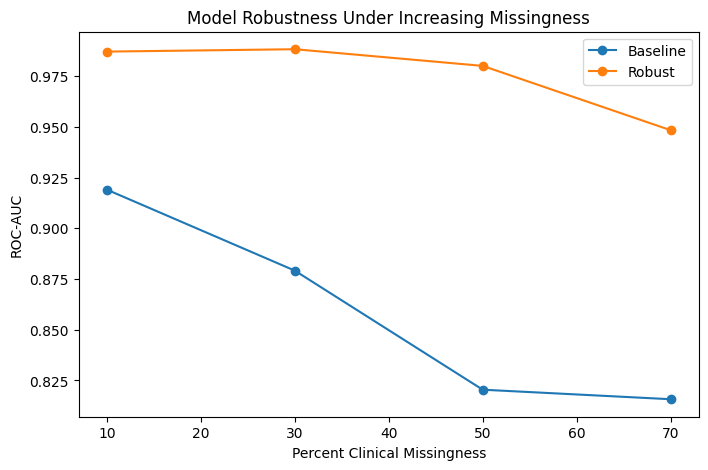

In [11]:
# =====================================================
# MISSINGNESS ROBUSTNESS EXPERIMENTS
# =====================================================
#
# This experiment evaluates:
#
# 1. Increasing missing clinical data
# 2. Baseline vs Robust models
# 3. MCAR missingness simulation
#
# MCAR = Missing Completely At Random
#
# =====================================================

missingness_levels = [
    0.1,
    0.3,
    0.5,
    0.7
]

# =====================================================
# STORE RESULTS
# =====================================================

missingness_results = []

# =====================================================
# LOOP THROUGH MISSINGNESS LEVELS
# =====================================================

for missing_rate in missingness_levels:

    print("\n====================================")
    print(f"MISSINGNESS LEVEL: {int(missing_rate*100)}%")
    print("====================================")

    # -----------------------------------------
    # CREATE MISSING TEST DATA
    # -----------------------------------------

    X_test_missing_partial = X_test.copy()

    # Randomly select rows
    mask = np.random.rand(
        len(X_test_missing_partial)
    ) < missing_rate

    # Remove clinical modality
    X_test_missing_partial.loc[
        mask,
        clinical_features
    ] = 0

    # -----------------------------------------
    # SCALE USING BASELINE SCALER
    # -----------------------------------------

    X_test_missing_partial_scaled = scaler.transform(
        X_test_missing_partial
    )

    # =====================================================
    # BASELINE MODEL PERFORMANCE
    # =====================================================

    baseline_probs = best_model.predict_proba(
        X_test_missing_partial_scaled
    )[:,1]

    baseline_auc = roc_auc_score(
        y_test,
        baseline_probs
    )

    # =====================================================
    # ROBUST MODEL PERFORMANCE
    # =====================================================

    X_test_missing_partial_scaled_robust = robust_scaler.transform(
        X_test_missing_partial
    )

    robust_probs = robust_model.predict_proba(
        X_test_missing_partial_scaled_robust
    )[:,1]

    robust_auc = roc_auc_score(
        y_test,
        robust_probs
    )

    # =====================================================
    # STORE RESULTS
    # =====================================================

    missingness_results.append({

        "Missingness": int(missing_rate * 100),

        "Baseline AUC": baseline_auc,

        "Robust AUC": robust_auc,

        "Baseline Drop": (
            results_df.iloc[0]["AUC"]
            -
            baseline_auc
        ),

        "Robust Drop": (
            robust_full_auc
            -
            robust_auc
        )
    })

    # =====================================================
    # PRINT RESULTS
    # =====================================================

    print("Baseline AUC:")
    print(baseline_auc)

    print("\nRobust AUC:")
    print(robust_auc)

# =====================================================
# RESULTS DATAFRAME
# =====================================================

missingness_df = pd.DataFrame(
    missingness_results
)

print("\n====================================")
print("MISSINGNESS EXPERIMENT RESULTS")
print("====================================")

print(missingness_df)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    missingness_df["Missingness"],
    missingness_df["Baseline AUC"],
    marker="o",
    label="Baseline"
)

plt.plot(
    missingness_df["Missingness"],
    missingness_df["Robust AUC"],
    marker="o",
    label="Robust"
)

plt.xlabel(
    "Percent Clinical Missingness"
)

plt.ylabel("ROC-AUC")

plt.title(
    "Model Robustness Under Increasing Missingness"
)

plt.legend()

plt.show()


Clinical Only
AUC: 0.9694835680751174

MRI Only
AUC: 0.8251173708920188

Multimodal
AUC: 0.9765258215962441

BASELINE MODALITY COMPARISON
      Model Type       AUC  Feature Count
2     Multimodal  0.976526             36
0  Clinical Only  0.969484              6
1       MRI Only  0.825117             30


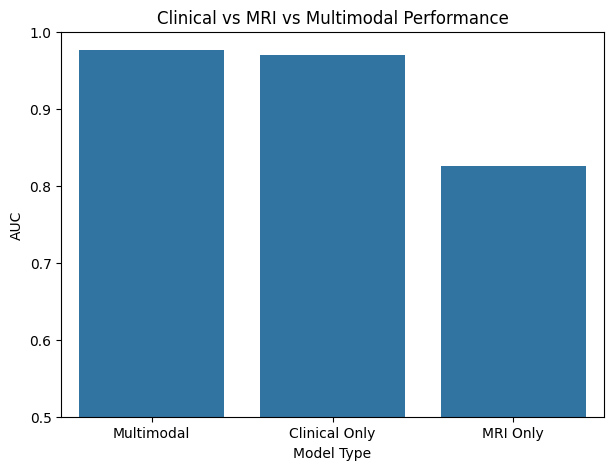

In [12]:
# =====================================================
# ADDITIONAL BASELINE EXPERIMENTS
# =====================================================
#
# Goal:
# Demonstrate:
#
# 1. Clinical-only performance
# 2. MRI-only performance
# 3. Multimodal performance
#
# This helps prove:
#
# - Multimodal learning matters
# - MRI contributes meaningful information
# - Robustness experiments are justified
#
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# =====================================================
# DEFINE FEATURE SETS
# =====================================================

clinical_only_features = clinical_features

mri_only_features = top_mri_features

multimodal_features = (
    clinical_features
    + top_mri_features
)

# =====================================================
# STORE RESULTS
# =====================================================

baseline_results = []

# =====================================================
# FEATURE SET LOOP
# =====================================================

feature_sets = {

    "Clinical Only": clinical_only_features,

    "MRI Only": mri_only_features,

    "Multimodal": multimodal_features
}

# =====================================================
# TRAIN + EVALUATE
# =====================================================

for name, features in feature_sets.items():

    print("\n====================================")
    print(name)
    print("====================================")

    # -----------------------------------------
    # BUILD DATA
    # -----------------------------------------

    X_subset = merged[features]

    # -----------------------------------------
    # TRAIN TEST SPLIT
    # -----------------------------------------

    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_subset,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    # -----------------------------------------
    # SCALE
    # -----------------------------------------

    scaler_b = StandardScaler()

    X_train_b_scaled = scaler_b.fit_transform(
        X_train_b
    )

    X_test_b_scaled = scaler_b.transform(
        X_test_b
    )

    # -----------------------------------------
    # MODEL
    # -----------------------------------------

    model_b = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    model_b.fit(
        X_train_b_scaled,
        y_train_b
    )

    # -----------------------------------------
    # PREDICT
    # -----------------------------------------

    probs_b = model_b.predict_proba(
        X_test_b_scaled
    )[:,1]

    auc_b = roc_auc_score(
        y_test_b,
        probs_b
    )

    # -----------------------------------------
    # STORE
    # -----------------------------------------

    baseline_results.append({

        "Model Type": name,

        "AUC": auc_b,

        "Feature Count": len(features)
    })

    print("AUC:", auc_b)

# =====================================================
# RESULTS DATAFRAME
# =====================================================

baseline_df = pd.DataFrame(
    baseline_results
)

baseline_df = baseline_df.sort_values(
    by="AUC",
    ascending=False
)

print("\n====================================")
print("BASELINE MODALITY COMPARISON")
print("====================================")

print(baseline_df)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(7,5))

sns.barplot(
    data=baseline_df,
    x="Model Type",
    y="AUC"
)

plt.ylim(0.5, 1.0)

plt.title(
    "Clinical vs MRI vs Multimodal Performance"
)

plt.show()

Prediction count: 83
y_test count: 83

HEALTHCARE EVALUATION METRICS
Accuracy:     0.952
Precision:    0.786
Recall:       0.917
F1-Score:     0.846
Sensitivity:  0.917
Specificity:  0.958
ROC-AUC:      0.977

METRICS TABLE
        Metric     Value
0     Accuracy  0.951807
1    Precision  0.785714
2       Recall  0.916667
3     F1-Score  0.846154
4  Sensitivity  0.916667
5  Specificity  0.957746
6      ROC-AUC  0.976526


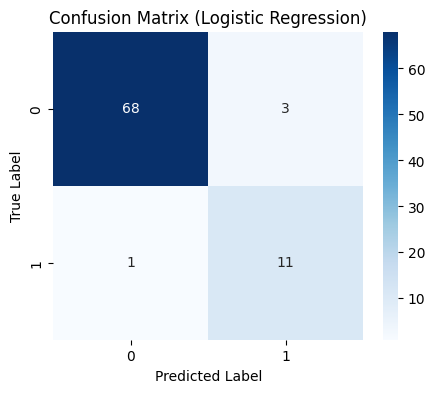


CONFUSION MATRIX INTERPRETATION
True Negatives (CN correctly identified): 68
False Positives (CN predicted as DEM): 3
False Negatives (DEM missed): 1
True Positives (DEM correctly identified): 11


In [16]:
# =====================================================
# REBUILD TRAIN / TEST DATA CLEANLY
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------------------
# TRAIN TEST SPLIT
# -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# -----------------------------------------
# SCALE
# -----------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# =====================================================
# RETRAIN BEST MODEL
# =====================================================

from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

best_model.fit(
    X_train_scaled,
    y_train
)

# =====================================================
# PREDICTIONS
# =====================================================

best_preds = best_model.predict(
    X_test_scaled
)

best_probs = best_model.predict_proba(
    X_test_scaled
)[:,1]

print("Prediction count:", len(best_preds))

print("y_test count:", len(y_test))

# =====================================================
# HEALTHCARE EVALUATION METRICS
# =====================================================
#
# Additional metrics commonly expected in:
#
# - Medical AI papers
# - Healthcare ML studies
# - Clinical prediction research
#
# Metrics:
#
# - Precision
# - Recall (Sensitivity)
# - F1-score
# - Specificity
# - Confusion Matrix
#
# =====================================================

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# =====================================================
# REGENERATE PREDICTIONS
# =====================================================

best_model.fit(
    X_train_scaled,
    y_train
)

best_preds = best_model.predict(
    X_test_scaled
)

best_probs = best_model.predict_proba(
    X_test_scaled
)[:,1]

# =====================================================
# CONFUSION MATRIX
# =====================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_preds
)

tn, fp, fn, tp = cm.ravel()

# =====================================================
# METRICS
# =====================================================

accuracy = accuracy_score(
    y_test,
    best_preds
)

precision = precision_score(
    y_test,
    best_preds
)

recall = recall_score(
    y_test,
    best_preds
)

f1 = f1_score(
    y_test,
    best_preds
)

# Sensitivity = Recall
sensitivity = recall

# Specificity
specificity = tn / (tn + fp)

# =====================================================
# PRINT METRICS
# =====================================================

print("\n====================================")
print("HEALTHCARE EVALUATION METRICS")
print("====================================")

print(f"Accuracy:     {accuracy:.3f}")

print(f"Precision:    {precision:.3f}")

print(f"Recall:       {recall:.3f}")

print(f"F1-Score:     {f1:.3f}")

print(f"Sensitivity:  {sensitivity:.3f}")

print(f"Specificity:  {specificity:.3f}")

print(f"ROC-AUC:      {results_df.iloc[0]['AUC']:.3f}")

# =====================================================
# RESULTS TABLE
# =====================================================

metrics_df = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Sensitivity",
        "Specificity",
        "ROC-AUC"
    ],

    "Value": [

        accuracy,
        precision,
        recall,
        f1,
        sensitivity,
        specificity,
        results_df.iloc[0]["AUC"]
    ]
})

print("\n====================================")
print("METRICS TABLE")
print("====================================")

print(metrics_df)

# =====================================================
# CONFUSION MATRIX VISUALIZATION
# =====================================================

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix ({best_model_name})"
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

# =====================================================
# CLASSIFICATION INTERPRETATION
# =====================================================

print("\n====================================")
print("CONFUSION MATRIX INTERPRETATION")
print("====================================")

print(f"True Negatives (CN correctly identified): {tn}")

print(f"False Positives (CN predicted as DEM): {fp}")

print(f"False Negatives (DEM missed): {fn}")

print(f"True Positives (DEM correctly identified): {tp}")


DROPOUT LEVEL: 0%
Full AUC:
0.9765258215962441

Missing-Modality AUC:
0.7711267605633803

Performance Drop:
0.20539906103286387

DROPOUT LEVEL: 10%
Full AUC:
0.9765258215962441

Missing-Modality AUC:
0.8169014084507042

Performance Drop:
0.15962441314553988

DROPOUT LEVEL: 30%
Full AUC:
0.9753521126760564

Missing-Modality AUC:
0.7922535211267605

Performance Drop:
0.18309859154929586

DROPOUT LEVEL: 50%
Full AUC:
0.9694835680751173

Missing-Modality AUC:
0.8274647887323944

Performance Drop:
0.1420187793427229

ABLATION RESULTS
   Dropout Rate  Full AUC  Missing AUC  Performance Drop
0             0  0.976526     0.771127          0.205399
1            10  0.976526     0.816901          0.159624
2            30  0.975352     0.792254          0.183099
3            50  0.969484     0.827465          0.142019


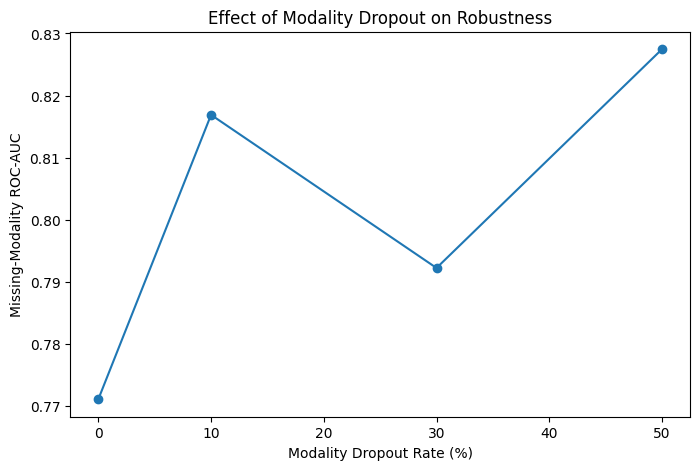

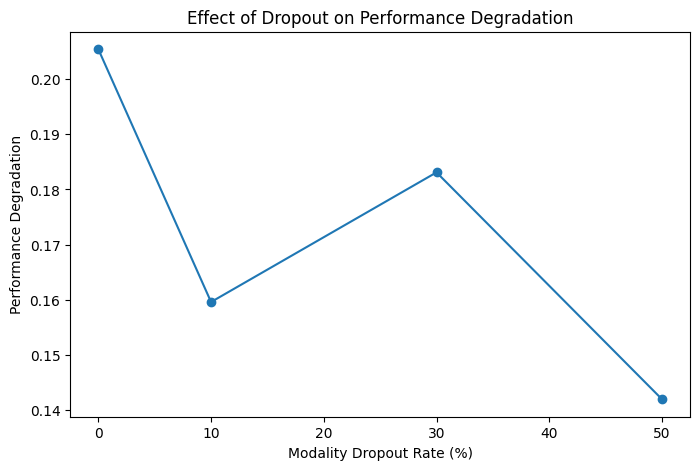

In [22]:
# =====================================================
# MODALITY DROPOUT ABLATION STUDY
# =====================================================

dropout_levels = [
    0.0,
    0.1,
    0.3,
    0.5
]

# =====================================================
# STORE RESULTS
# =====================================================

ablation_results = []

# =====================================================
# LOOP THROUGH DROPOUT LEVELS
# =====================================================

for dropout_rate in dropout_levels:

    print("\n====================================")
    print(f"DROPOUT LEVEL: {int(dropout_rate * 100)}%")
    print("====================================")

    # -----------------------------------------
    # COPY TRAIN DATA
    # -----------------------------------------

    X_train_ablation = X_train.copy()

    # -----------------------------------------
    # APPLY MODALITY DROPOUT
    # -----------------------------------------

    if dropout_rate > 0:

        mask = np.random.rand(
            len(X_train_ablation)
        ) < dropout_rate

        X_train_ablation.loc[
            mask,
            clinical_features
        ] = 0

    # -----------------------------------------
    # SCALE
    # -----------------------------------------

    scaler_ablation = StandardScaler()

    X_train_ablation_scaled = scaler_ablation.fit_transform(
        X_train_ablation
    )

    X_test_scaled_ablation = scaler_ablation.transform(
        X_test
    )

    # -----------------------------------------
    # CREATE FRESH MISSING TEST SET
    # -----------------------------------------

    X_test_missing_ablation = X_test.copy()

    X_test_missing_ablation[
        clinical_features
    ] = 0

    # -----------------------------------------
    # SCALE MISSING TEST SET
    # -----------------------------------------

    X_test_missing_scaled_ablation = scaler_ablation.transform(
        X_test_missing_ablation
    )

    # -----------------------------------------
    # TRAIN MODEL
    # -----------------------------------------

    ablation_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    ablation_model.fit(
        X_train_ablation_scaled,
        y_train
    )

    # -----------------------------------------
    # FULL PERFORMANCE
    # -----------------------------------------

    full_probs = ablation_model.predict_proba(
        X_test_scaled_ablation
    )[:, 1]

    full_auc = roc_auc_score(
        y_test,
        full_probs
    )

    # -----------------------------------------
    # MISSING PERFORMANCE
    # -----------------------------------------

    missing_probs = ablation_model.predict_proba(
        X_test_missing_scaled_ablation
    )[:, 1]

    missing_auc = roc_auc_score(
        y_test,
        missing_probs
    )

    # -----------------------------------------
    # PERFORMANCE DROP
    # -----------------------------------------

    performance_drop = (
        full_auc - missing_auc
    )

    # -----------------------------------------
    # STORE RESULTS
    # -----------------------------------------

    ablation_results.append({

        "Dropout Rate": int(dropout_rate * 100),

        "Full AUC": full_auc,

        "Missing AUC": missing_auc,

        "Performance Drop": performance_drop
    })

    # -----------------------------------------
    # PRINT RESULTS
    # -----------------------------------------

    print("Full AUC:")
    print(full_auc)

    print("\nMissing-Modality AUC:")
    print(missing_auc)

    print("\nPerformance Drop:")
    print(performance_drop)

# =====================================================
# RESULTS DATAFRAME
# =====================================================

ablation_df = pd.DataFrame(
    ablation_results
)

print("\n====================================")
print("ABLATION RESULTS")
print("====================================")

print(ablation_df)

# =====================================================
# VISUALIZATION
# =====================================================

plt.figure(figsize=(8, 5))

plt.plot(
    ablation_df["Dropout Rate"],
    ablation_df["Missing AUC"],
    marker="o"
)

plt.xlabel(
    "Modality Dropout Rate (%)"
)

plt.ylabel(
    "Missing-Modality ROC-AUC"
)

plt.title(
    "Effect of Modality Dropout on Robustness"
)

plt.show()

# =====================================================
# PERFORMANCE DROP VISUALIZATION
# =====================================================

plt.figure(figsize=(8, 5))

plt.plot(
    ablation_df["Dropout Rate"],
    ablation_df["Performance Drop"],
    marker="o"
)

plt.xlabel(
    "Modality Dropout Rate (%)"
)

plt.ylabel(
    "Performance Degradation"
)

plt.title(
    "Effect of Dropout on Performance Degradation"
)

plt.show()